In [ ]:
!pip -q install torch torchvision pillow pandas numpy h5py gdown tqdm

In [ ]:
import os
import random
import shutil
from pathlib import Path

import numpy as np
import pandas as pd
from PIL import Image
from tqdm import tqdm

import torch
import torchvision
from torchvision.datasets import PCAM

print("Torch version:", torch.__version__)
print("Torchvision version:", torchvision.__version__)

# Main working folders
ROOT = Path("/content/pcam_project")
RAW_DIR = ROOT / "raw"
OUT_DIR = ROOT / "pcam_subset_ready"
META_DIR = OUT_DIR / "metadata"

ROOT.mkdir(parents=True, exist_ok=True)
RAW_DIR.mkdir(parents=True, exist_ok=True)
META_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", ROOT)

Torch version: 2.10.0+cpu
Torchvision version: 0.25.0+cpu
Project root: /content/pcam_project


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from pathlib import Path

ROOT = Path("/content/drive/MyDrive/pcam_project")
RAW_DIR = ROOT / "raw"
OUT_DIR = ROOT / "pcam_subset_ready"
META_DIR = OUT_DIR / "metadata"

ROOT.mkdir(parents=True, exist_ok=True)
RAW_DIR.mkdir(parents=True, exist_ok=True)
META_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", ROOT)

Project root: /content/drive/MyDrive/pcam_project


In [ ]:
!pip -q install gdown h5py tqdm pandas pillow numpy

In [ ]:
import os

raw_path = "/content/drive/MyDrive/pcam_project/raw"
print(os.listdir(raw_path))

['camelyonpatch_level_2_split_train_x.h5', 'camelyonpatch_level_2_split_valid_x.h5', 'camelyonpatch_level_2_split_test_x.h5']


In [ ]:
import os
import random
import shutil
from pathlib import Path

import h5py
import numpy as np
import pandas as pd
from PIL import Image
from tqdm import tqdm

In [ ]:
ROOT = Path("/content/drive/MyDrive/pcam_project")
RAW_DIR = ROOT / "raw"
OUT_DIR = ROOT / "pcam_subset_ready"
META_DIR = OUT_DIR / "metadata"

ROOT.mkdir(parents=True, exist_ok=True)
RAW_DIR.mkdir(parents=True, exist_ok=True)
META_DIR.mkdir(parents=True, exist_ok=True)

print("ROOT:", ROOT)
print("RAW_DIR:", RAW_DIR)
print("OUT_DIR:", OUT_DIR)

ROOT: /content/drive/MyDrive/pcam_project
RAW_DIR: /content/drive/MyDrive/pcam_project/raw
OUT_DIR: /content/drive/MyDrive/pcam_project/pcam_subset_ready


In [ ]:
for split in ["train", "val", "test"]:
    (OUT_DIR / "clean" / split).mkdir(parents=True, exist_ok=True)

    (OUT_DIR / "denoising" / split / "input").mkdir(parents=True, exist_ok=True)
    (OUT_DIR / "denoising" / split / "target").mkdir(parents=True, exist_ok=True)

    (OUT_DIR / "super_resolution" / split / "input").mkdir(parents=True, exist_ok=True)
    (OUT_DIR / "super_resolution" / split / "target").mkdir(parents=True, exist_ok=True)
    (OUT_DIR / "super_resolution" / split / "true_lr").mkdir(parents=True, exist_ok=True)

print("Folders created successfully.")

Folders created successfully.


In [ ]:
train_file = RAW_DIR / "camelyonpatch_level_2_split_train_x.h5"

with h5py.File(train_file, "r") as f:
    print("Keys inside train H5:", list(f.keys()))

Keys inside train H5: ['x']


In [ ]:
with h5py.File(train_file, "r") as f:
    x_data = f["x"]
    print("Shape:", x_data.shape)
    print("Dtype:", x_data.dtype)

Shape: (262144, 96, 96, 3)
Dtype: uint8


In [ ]:
SUBSET_SIZES = {
    "train": 100,
    "val": 20,
    "test": 20
}

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

print(SUBSET_SIZES)

{'train': 100, 'val': 20, 'test': 20}


In [ ]:
def extract_clean_subset_from_h5(h5_path, split, n_samples, dataset_key="x"):
    rows = []

    with h5py.File(h5_path, "r") as f:
        x_data = f[dataset_key]
        total_images = x_data.shape[0]

        indices = list(range(total_images))
        random.shuffle(indices)
        selected = indices[:n_samples]

        for i, idx in enumerate(tqdm(selected, desc=f"Extracting clean {split}")):
            img_array = x_data[idx]   # shape: (96, 96, 3)

            # Convert numpy array to PIL image
            img = Image.fromarray(img_array)

            filename = f"{split}_{i:04d}.png"
            save_path = OUT_DIR / "clean" / split / filename
            img.save(save_path)

            rows.append({
                "image_id": f"{split}_{i:04d}",
                "source_index": idx,
                "clean_path": str(save_path)
            })

    df = pd.DataFrame(rows)
    df.to_csv(META_DIR / f"clean_{split}.csv", index=False)
    return df

In [ ]:
train_h5 = RAW_DIR / "camelyonpatch_level_2_split_train_x.h5"
val_h5   = RAW_DIR / "camelyonpatch_level_2_split_valid_x.h5"
test_h5  = RAW_DIR / "camelyonpatch_level_2_split_test_x.h5"

clean_train_df = extract_clean_subset_from_h5(train_h5, "train", SUBSET_SIZES["train"])
clean_val_df   = extract_clean_subset_from_h5(val_h5,   "val",   SUBSET_SIZES["val"])
clean_test_df  = extract_clean_subset_from_h5(test_h5,  "test",  SUBSET_SIZES["test"])

print("Clean subset extraction complete.")

Extracting clean test: 100%|██████████| 20/20 [00:10<00:00,  1.82it/s]

Clean subset extraction complete.


Sample image size: (96, 96)


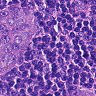

In [ ]:
sample_img = Image.open(OUT_DIR / "clean" / "train" / "train_0000.png")
print("Sample image size:", sample_img.size)
sample_img

In [ ]:
SIGMA = 0.1  # noise level on [0,1] scale

def add_gaussian_noise(pil_img, sigma=0.1):
    arr = np.array(pil_img).astype(np.float32) / 255.0
    noise = np.random.normal(0, sigma, arr.shape).astype(np.float32)
    noisy = np.clip(arr + noise, 0.0, 1.0)
    noisy = (noisy * 255.0).astype(np.uint8)
    return Image.fromarray(noisy)

In [ ]:
def create_denoising_split(split):
    clean_dir = OUT_DIR / "clean" / split
    input_dir = OUT_DIR / "denoising" / split / "input"
    target_dir = OUT_DIR / "denoising" / split / "target"

    rows = []
    clean_files = sorted(clean_dir.glob("*.png"))

    for clean_path in tqdm(clean_files, desc=f"Creating denoising {split}"):
        img = Image.open(clean_path).convert("RGB")
        noisy_img = add_gaussian_noise(img, sigma=SIGMA)

        filename = clean_path.name
        noisy_path = input_dir / filename
        target_path = target_dir / filename

        noisy_img.save(noisy_path)
        img.save(target_path)

        rows.append({
            "image_id": clean_path.stem,
            "input_path": str(noisy_path),
            "target_path": str(target_path),
            "noise_type": "gaussian",
            "sigma": SIGMA
        })

    df = pd.DataFrame(rows)
    df.to_csv(META_DIR / f"denoising_{split}.csv", index=False)
    return df

In [ ]:
den_train_df = create_denoising_split("train")
den_val_df   = create_denoising_split("val")
den_test_df  = create_denoising_split("test")

print("Denoising subset ready.")

Creating denoising test: 100%|██████████| 20/20 [00:00<00:00, 28.35it/s]

Denoising subset ready.


Clean size: (96, 96)
Noisy size: (96, 96)


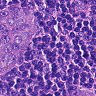

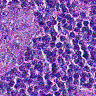

In [ ]:
clean_img = Image.open(OUT_DIR / "denoising" / "train" / "target" / "train_0000.png")
noisy_img = Image.open(OUT_DIR / "denoising" / "train" / "input" / "train_0000.png")

print("Clean size:", clean_img.size)
print("Noisy size:", noisy_img.size)

display(clean_img)
display(noisy_img)

In [ ]:
SR_SCALE = 4

def create_sr_images(pil_img, scale=4):
    hr = pil_img.convert("RGB")
    w, h = hr.size

    lr_w, lr_h = w // scale, h // scale
    true_lr = hr.resize((lr_w, lr_h), Image.BICUBIC)

    # Upsample back to original size for model input
    sr_input = true_lr.resize((w, h), Image.BICUBIC)

    return sr_input, hr, true_lr

In [ ]:
def create_sr_split(split):
    clean_dir = OUT_DIR / "clean" / split
    input_dir = OUT_DIR / "super_resolution" / split / "input"
    target_dir = OUT_DIR / "super_resolution" / split / "target"
    true_lr_dir = OUT_DIR / "super_resolution" / split / "true_lr"

    rows = []
    clean_files = sorted(clean_dir.glob("*.png"))

    for clean_path in tqdm(clean_files, desc=f"Creating SR {split}"):
        img = Image.open(clean_path).convert("RGB")
        sr_input, hr, true_lr = create_sr_images(img, scale=SR_SCALE)

        filename = clean_path.name
        input_path = input_dir / filename
        target_path = target_dir / filename
        true_lr_path = true_lr_dir / filename

        sr_input.save(input_path)
        hr.save(target_path)
        true_lr.save(true_lr_path)

        rows.append({
            "image_id": clean_path.stem,
            "input_path": str(input_path),
            "target_path": str(target_path),
            "true_lr_path": str(true_lr_path),
            "scale_factor": SR_SCALE,
            "target_size": "96x96",
            "true_lr_size": f"{96 // SR_SCALE}x{96 // SR_SCALE}"
        })

    df = pd.DataFrame(rows)
    df.to_csv(META_DIR / f"sr_{split}.csv", index=False)
    return df

In [ ]:
sr_train_df = create_sr_split("train")
sr_val_df   = create_sr_split("val")
sr_test_df  = create_sr_split("test")

print("Super-resolution subset ready.")

Creating SR test: 100%|██████████| 20/20 [00:00<00:00, 21.81it/s]

Super-resolution subset ready.


SR input size: (96, 96)
SR target size: (96, 96)
True LR size: (24, 24)


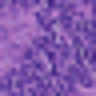

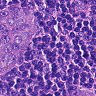

In [ ]:
sr_input = Image.open(OUT_DIR / "super_resolution" / "train" / "input" / "train_0000.png")
sr_target = Image.open(OUT_DIR / "super_resolution" / "train" / "target" / "train_0000.png")
true_lr = Image.open(OUT_DIR / "super_resolution" / "train" / "true_lr" / "train_0000.png")

print("SR input size:", sr_input.size)
print("SR target size:", sr_target.size)
print("True LR size:", true_lr.size)

display(sr_input)
display(sr_target)
display(true_lr)

### Here, we downsampled the clean image to simulate low resolution, then upsampled it back using bicubic interpolation to create the input, while keeping the original image as the target.

In [ ]:
for csv_file in sorted(META_DIR.glob("*.csv")):
    df = pd.read_csv(csv_file)
    print(csv_file.name, "->", len(df), "rows")

clean_test.csv -> 20 rows
clean_train.csv -> 100 rows
clean_val.csv -> 20 rows
denoising_test.csv -> 20 rows
denoising_train.csv -> 100 rows
denoising_val.csv -> 20 rows
sr_test.csv -> 20 rows
sr_train.csv -> 100 rows
sr_val.csv -> 20 rows


In [ ]:
for root, dirs, files in os.walk(OUT_DIR):
    level = root.replace(str(OUT_DIR), "").count(os.sep)
    indent = " " * 2 * level
    print(f"{indent}{Path(root).name}/")
    subindent = " " * 2 * (level + 1)
    for f in files[:5]:
        print(f"{subindent}{f}")

pcam_subset_ready/
  metadata/
    clean_train.csv
    clean_val.csv
    clean_test.csv
    denoising_train.csv
    denoising_val.csv
  clean/
    train/
      train_0000.png
      train_0001.png
      train_0002.png
      train_0003.png
      train_0004.png
    val/
      val_0000.png
      val_0001.png
      val_0002.png
      val_0003.png
      val_0004.png
    test/
      test_0000.png
      test_0001.png
      test_0002.png
      test_0003.png
      test_0004.png
  denoising/
    train/
      input/
        train_0000.png
        train_0001.png
        train_0002.png
        train_0003.png
        train_0004.png
      target/
        train_0000.png
        train_0001.png
        train_0002.png
        train_0003.png
        train_0004.png
    val/
      input/
        val_0000.png
        val_0001.png
        val_0002.png
        val_0003.png
        val_0004.png
      target/
        val_0000.png
        val_0001.png
        val_0002.png
        val_0003.png
        val_0004.png


In [ ]:
zip_base = ROOT / "pcam_subset_ready"
zip_file = Path(str(zip_base) + ".zip")

if zip_file.exists():
    zip_file.unlink()

shutil.make_archive(str(zip_base), "zip", OUT_DIR)

print("Zip created:", zip_file)
print("Zip size (MB):", round(zip_file.stat().st_size / (1024 * 1024), 2))

Zip created: /content/drive/MyDrive/pcam_project/pcam_subset_ready.zip
Zip size (MB): 14.69


In [ ]:
from google.colab import files
files.download(str(zip_file))

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>